<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/healthcare/object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os
import matplotlib.pyplot as plt
import matplotlib.image as pltimg
import numpy as np
import pandas as pd
import cv2
import torch
import re
from PIL import Image
from torchvision import transforms
from torch import nn
from time import time
import albumentations as A

In [2]:
# check if the gpu is available or not
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
# connect to dataset drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
# upload the dataset
!unzip /content/drive/MyDrive/Healthcare/BUSI/BUSI_Jpeg.zip

In [5]:
data_path = ['benign', 'benign_mask', 'malignant', 'malignant_mask']

# check the files and folders
for path in data_path:
  for root, dirs, files in os.walk(path):
    print(f'There are {len(dirs)} directories and  {len(files)} files in "/{root}"')

There are 0 directories and  437 files in "/benign"
There are 0 directories and  455 files in "/benign_mask"
There are 0 directories and  210 files in "/malignant"
There are 0 directories and  212 files in "/malignant_mask"


In [6]:
# Make sure to get the right image file
def extract_idx(filename):
  """
  Extract index from the filename
  """
  index = re.search(r'\((\d+)\)', filename)
  if index is not None:
    return int(index.group(1))
  else: return -1

def is_valid_image(filename, prefix, is_mask=False):
  """
  Make sure the file and the pattern in the dataset match in order to avoid duplicate images
  """
  if is_mask:
    pattern = rf'{prefix} \(\d+\)_mask\.png$'
  else:
      pattern = rf'{prefix} \(\d+\)\.png$'
  return re.match(pattern, filename)

In [7]:
"""
  Clean up the images directories
  read all images in the directory -> extract only images by index in the file -> validate to remove duplicate or invalid image
  sort them based on the index
"""
benign = sorted(
    [f for f in os.listdir('benign') if extract_idx(f) != -1 and is_valid_image(f, 'benign', False)],
    key=extract_idx)
benign_mask = sorted(
    [f for f in os.listdir('benign_mask') if extract_idx(f) != -1 and is_valid_image(f, 'benign', True)],
    key=extract_idx)
malignant = sorted(
    [f for f in os.listdir('malignant') if extract_idx(f) != -1 and is_valid_image(f, 'malignant', False)],
    key=extract_idx)
malignant_mask = sorted(
    [f for f in os.listdir('malignant_mask') if extract_idx(f) != -1 and is_valid_image(f, 'malignant', True)],
    key=extract_idx)

In [8]:
len(benign), len(benign_mask), len(malignant), len(malignant_mask)

(437, 437, 210, 210)

In [ ]:
# plot a random image from each classes
def plot_img_with_mask(depth, root):
  idx = np.random.randint(0, depth)
  fig, ax = plt.subplots(1, 5, figsize=(15, 4))

  # orignal image
  org_img = pltimg.imread(f'{root}/{root} ({idx}).png')
  # mask image
  mask_img = pltimg.imread(f'{root}_mask/{root} ({idx})_mask.png')

  # plot orinal img
  ax[0].imshow(org_img)
  ax[0].set_title(f"Orignal {root} ({idx})")
  ax[0].set_xticks([])
  ax[0].set_yticks([])

  # plot the mask img
  ax[1].imshow(mask_img)
  ax[1].set_title(f"Mask {root} ({idx})")
  ax[1].set_xticks([])
  ax[1].set_yticks([])


  print(f'maks_img shape: {mask_img.shape}')

  # add threshold for the mask image
  if len(mask_img.shape) == 3: # <-- if the image is not already in 1 chanel(gray scale)
    imgray = cv2.cvtColor(mask_img, cv2.COLOR_BGR2GRAY)
  else:
    imgray = mask_img

  imgray = (imgray * 255).astype("uint8") # <-- change image type
  _, threshold = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)
  contours, hierarchy = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

  # plot the contours image
  contours_img = cv2.drawContours(mask_img, contours, -1, (127,255,0), 2)
  ax[2].imshow(contours_img)
  ax[2].set_title(f"Contours {root} ({idx})")
  ax[2].set_xticks([])
  ax[2].set_yticks([])

  # masked the original image
  controus_img = org_img.copy()
  contours_org_img = cv2.drawContours(controus_img, contours, -1, (127, 255, 0), 2)
  ax[3].imshow(contours_org_img)
  ax[3].set_title(f'Masked {root} ({idx})', color='red')
  ax[3].set_xticks([])
  ax[3].set_yticks([])

  # Contours bounding box
  bound_img = org_img.copy()
  for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(bound_img, (x, y), (x+w, y+h), (0, 255, 0, 0), 4)
  ax[4].imshow(bound_img)
  ax[4].set_title(f'Bounding Contours {root} ({idx})', color='red')
  ax[4].set_xticks([])
  ax[4].set_yticks([])

  plt.tight_layout()

maks_img shape: (468, 563)


maks_img shape: (473, 551)


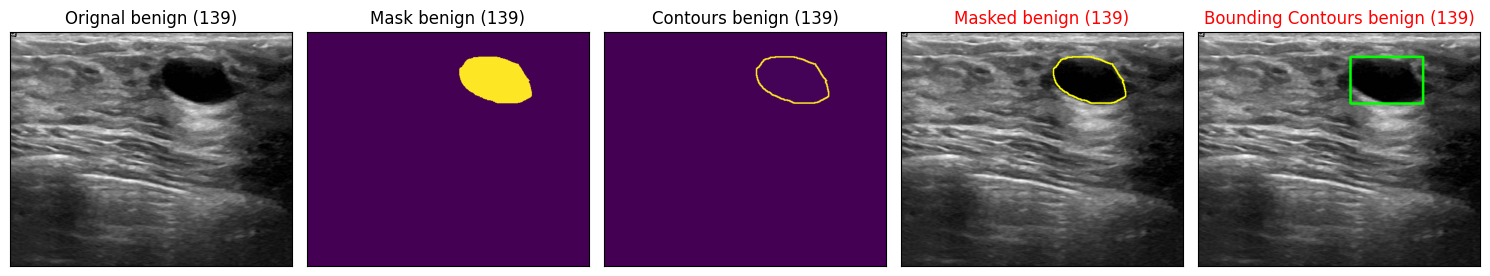

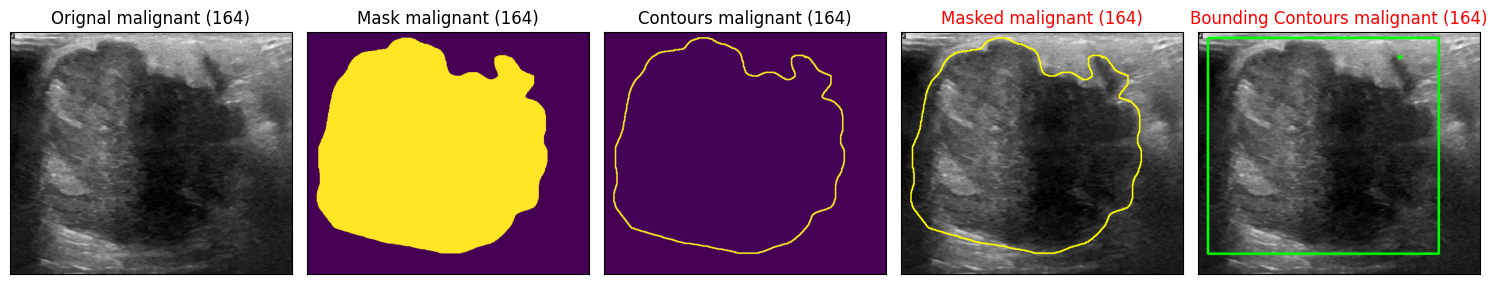

In [ ]:
plot_img_with_mask(len(benign), 'benign')
plot_img_with_mask(len(malignant), 'malignant')

227 128 67 62


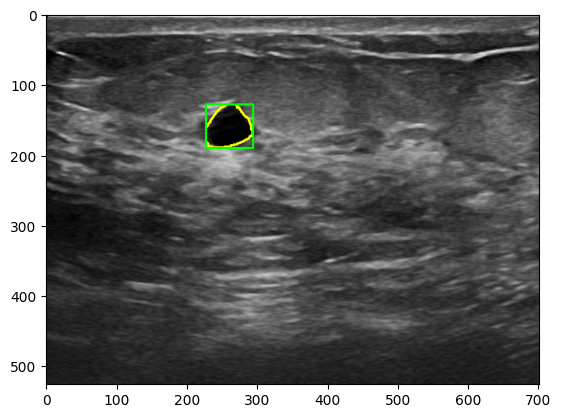

In [ ]:
# add threshold for the mask image
# orignal image
org_img = pltimg.imread(f'benign/benign (15).png')
# mask image
mask_img = pltimg.imread(f'benign_mask/benign (15)_mask.png')

if len(mask_img.shape) == 3: # <-- if the image is not already in 1 chanel(gray scale)
  imgray = cv2.cvtColor(mask_img, cv2.COLOR_BGR2GRAY)
else:
  imgray = mask_img

imgray = (imgray * 255).astype("uint8") # <-- change image type
_, threshold = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

contours_org_img = cv2.drawContours(org_img, contours, -1, (127, 255, 0), 2)
for cnt in contours:
  x, y, w, h = cv2.boundingRect(cnt)
  print(x, y, w, h)
  cv2.rectangle(contours_org_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.imshow(contours_org_img)


In [8]:
# Denormalize method for displying normalized image
g_mean = [0.485, 0.456, 0.406]
g_std = [0.229, 0.224, 0.225]
def denormalize(img):
    if isinstance(img, torch.Tensor):
        mean = torch.tensor(g_mean, device=img.device)
        std = torch.tensor(g_std, device=img.device)
        return img * std[:, None, None] + mean[:, None, None]

    elif isinstance(img, np.ndarray):
        mean = np.array(g_mean)
        std = np.array(g_std)
        return img * std[None, None, :] + mean[None, None, :]

In [17]:
# Providing the mask get the boundry box
def get_bbox_and_cnt(mask):
  if len(mask.shape) == 3:
    imgray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
  else:
    imgray = mask

  imgray = (imgray * 255).astype("uint8") # <-- change image type
  _, threshold = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)

  # get the contours
  contours, _ = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
  if len(contours)==0:
    return None

  # take the largest contour
  cnt = max(contours, key=cv2.contourArea)
  # get the bounding box
  x, y, w, h = cv2.boundingRect(cnt)

  return contours, [x, y, w, h]

In [10]:
# splitting the Benign to training and testing
def split_dataset(data):
  train_size = int(0.7 * len(data)) # 70%
  valid_size = int(0.2 * len(data)) # 20%
  test_size = len(data) - train_size - valid_size # 10%
  generator = torch.Generator().manual_seed(0)
  train, val, test = torch.utils.data.random_split(data, [train_size, valid_size, test_size], generator=generator)
  return train, val, test

In [9]:
class Dataset(torch.utils.data.Dataset):
  def __init__(self, img_list, mask_list, img_dir, mask_dir, transform=None, image_size=None):
    self.img_list = img_list
    self.mask_list = mask_list
    self.img_dir = img_dir
    self.mask_dir = mask_dir
    self.transform = transform
    self.image_size = image_size

  def __len__(self):
    return len(self.img_list)

  def __getitem__(self, index):
    image_path = os.path.join(self.img_dir, self.img_list[index])
    mask_path = os.path.join(self.mask_dir, self.mask_list[index])

    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path)

    image = np.array(image)
    mask = np.array(mask)

    _, bbox = get_bbox_and_cnt(mask)
    if bbox is None:
      bbox = [0, 0, 0, 0]
    if self.transform:
      result = self.transform(image=image, bboxes=[bbox])
      image = result['image']
      bbox = result['bboxes'][0]

    bbox = np.array(bbox)/self.image_size

    return image.float(), torch.tensor(bbox, dtype=torch.float32)

In [13]:
# Create a Augmentation Pipeline
img_size = 300
train_transform_pipeline = A.Compose([
    A.Resize(img_size, img_size),

    # Geometric
    A.HorizontalFlip(p=0.2),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        p=0.3
    ),

    A.ElasticTransform(alpha=1, sigma=50, p=0.2), # Simulates tissue deformation
    A.GridDistortion(p=0.2),

    # Light intensity changes
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(std_range=(0.1, 0.5), p=0.1),

    A.GaussianBlur(
         sigma_limit=(0.2, 0.5),  # Small sigma for subtle blur
         blur_limit=0,            # Auto-compute kernel size
         p=0.2
     ),

    A.Normalize(mean=g_mean, std=g_std ),
    A.pytorch.ToTensorV2(),
],
bbox_params=A.BboxParams(format='coco', min_visibility=0.3, label_fields=[]))
validation_transform_pipeline = A.Compose([
    A.Resize(img_size, img_size),
    A.Normalize(mean=g_mean, std=g_std ),
    A.pytorch.ToTensorV2(),
],
bbox_params=A.BboxParams(format='coco', min_visibility=0.3, label_fields=[]))

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [14]:
# Get all the dataset
train_data, val_data, test_data = split_dataset(benign)
train_mask, val_mask, test_mask = split_dataset(benign_mask)
benign_train = Dataset(train_data, train_mask, 'benign', 'benign_mask', transform=train_transform_pipeline, image_size=img_size)
benign_val = Dataset(val_data, val_mask, 'benign', 'benign_mask', transform=validation_transform_pipeline, image_size=img_size)
benign_test = Dataset(test_data, test_mask, 'benign', 'benign_mask', transform=validation_transform_pipeline, image_size=img_size)

In [15]:
img, label = benign_train.__getitem__(1)
img.shape, label.shape

(torch.Size([3, 300, 300]), torch.Size([4]))

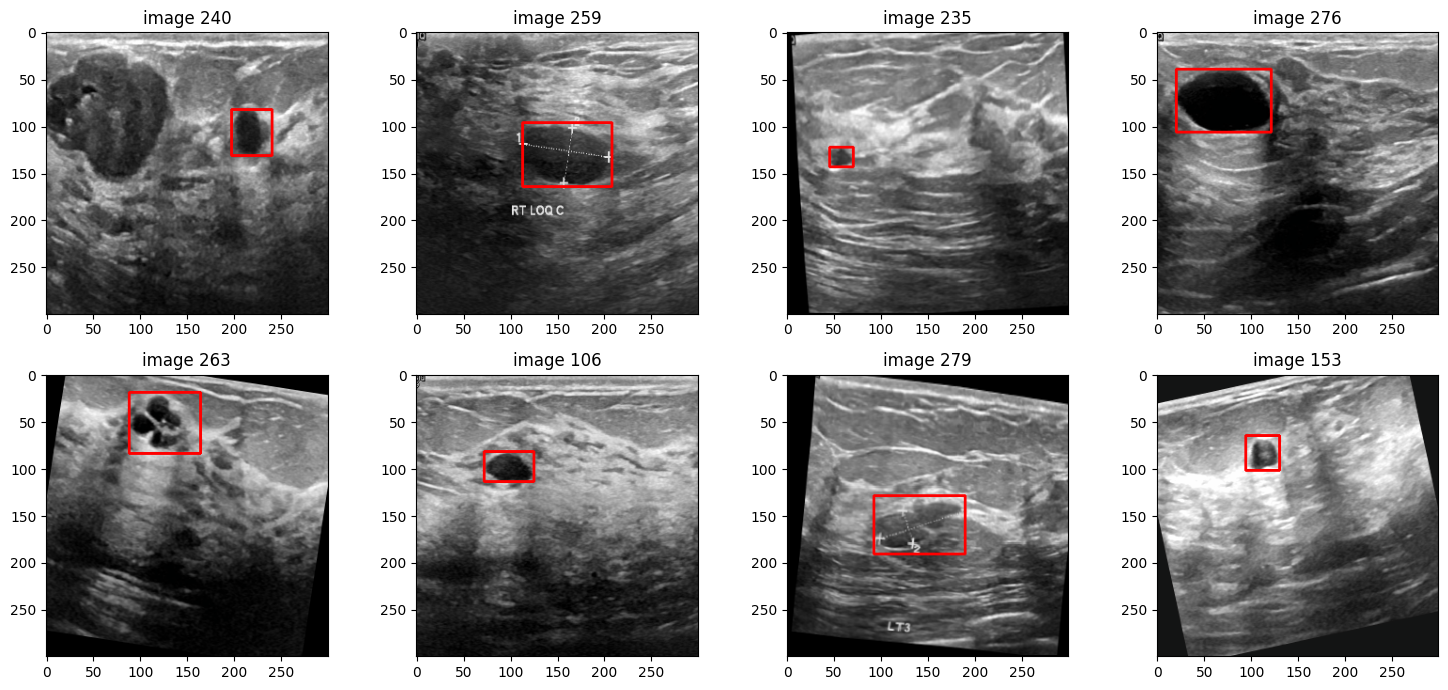

In [ ]:
# plot some augmented images
plt.figure(figsize=(15, 7))
for i in range(8):
  idx = np.random.randint(0, len(benign_train))
  img, box = benign_train.__getitem__(idx)

  img = img.permute(1,2,0).cpu().numpy()
  h_img, w_img, _ = img.shape

  x, y, w, h = box

  # 1. convert to pixel space
  x = x.item() * w_img
  y = y.item() * h_img
  w = w.item() * w_img
  h = h.item() * h_img

  # 2. fix negatives
  x = max(0, int(x))
  y = max(0, int(y))
  w = max(1, int(w))
  h = max(1, int(h))

  plt.subplot(2, 4, i+1)
  denorm_img = denormalize(img)
  bound_img = cv2.rectangle(denorm_img.copy(),
                            (x, y),
                            (x+w, y+h),
                            (255, 0, 0),
                            2)
  plt.imshow(bound_img)
  plt.title(f"image {idx}")
plt.tight_layout()

In [16]:
start_time = time()
train_dir = "benign_dataset/train"
val_dir = "benign_dataset/val"
# create directory if it doesn't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
for i in range(len(benign_train)):
    tr_image, tr_label = benign_train[i]   # <-- NOW data is loaded
    torch.save((tr_image, tr_label), f"{train_dir}/benign_{i}.pt")

for i in range(len(benign_val)):
    val_image, val_label = benign_val[i]
    torch.save((val_image, val_label), f"{val_dir}/benign_{i}.pt")
print(f'tokes {time()-start_time}s')

tokes 11.707877159118652s


In [11]:
class CachedDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir):
        self.files = os.listdir(data_dir)
        self.data_dir = data_dir

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.data_dir, self.files[idx])
        image, bbox = torch.load(path, weights_only=False)
        return image, bbox

In [18]:
train_dataset = CachedDataset(train_dir)
val_dataset = CachedDataset(val_dir)
len(train_dataset), len(val_dataset)

(305, 87)

In [19]:
# add data loader
ben_train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=32, num_workers=2, shuffle=True, drop_last=True)
ben_valid_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=32, num_workers=2, shuffle=True)

In [20]:
len(ben_train_loader.dataset), len(ben_valid_loader.dataset)

(305, 87)

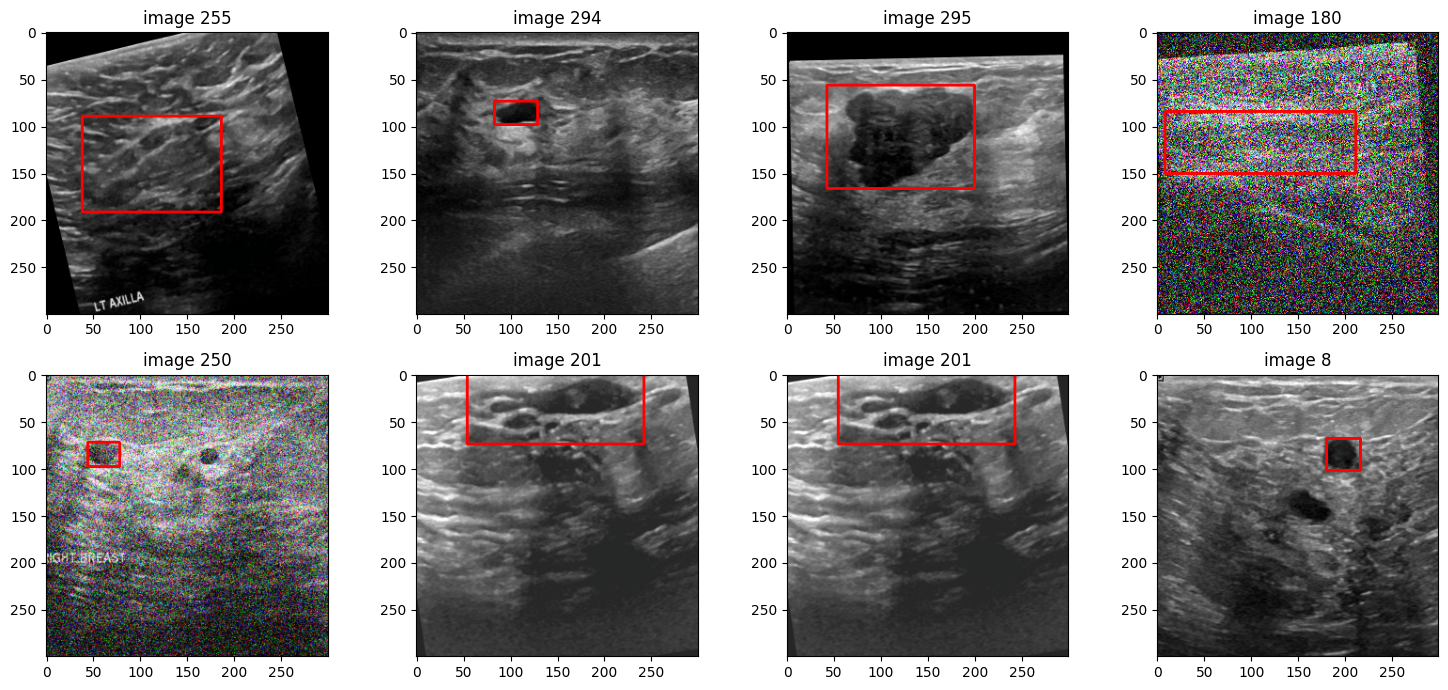

In [27]:
# plot some augmented images with bbox
plt.figure(figsize=(15, 7))
for i in range(8):
  idx = np.random.randint(0, len(ben_train_loader.dataset))
  img, box = ben_train_loader.dataset.__getitem__(idx)

  img = img.permute(1,2,0).cpu().numpy()
  h_img, w_img, _ = img.shape

  x, y, w, h = box

  # 1. convert to pixel space
  x = x.item() * w_img
  y = y.item() * h_img
  w = w.item() * w_img
  h = h.item() * h_img

  # 2. fix negatives
  x = max(0, int(x))
  y = max(0, int(y))
  w = max(1, int(w))
  h = max(1, int(h))

  plt.subplot(2, 4, i+1)
  denorm_img = denormalize(img)
  bound_img = cv2.rectangle(denorm_img.copy(),
                            (x, y),
                            (x+w, y+h),
                            (255, 0, 0),
                            2)
  plt.imshow(bound_img)
  plt.title(f"image {idx}")
plt.tight_layout()

In [12]:
# create Residual with skip connection support
class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, stride=stride),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),

            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c)
        )

        # match dimensions for skip connection
        if in_c != out_c or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_c)
            )
        else:
            self.skip = nn.Identity()

        self.relu = nn.ReLU()

    def forward(self, x):
        residual = self.skip(x)      # original path

        out = self.conv(x)           # transformed path

        out = out + residual
        out = self.relu(out)  #  RESIDUAL ADDED

        return out

**ResNet Encoder + U-Net Decoder (ResUNet)**
```
Input → Encoder (ResBlocks ↓) → Bottleneck
      → Decoder (↑ + Skip connections) → Output Mask
```

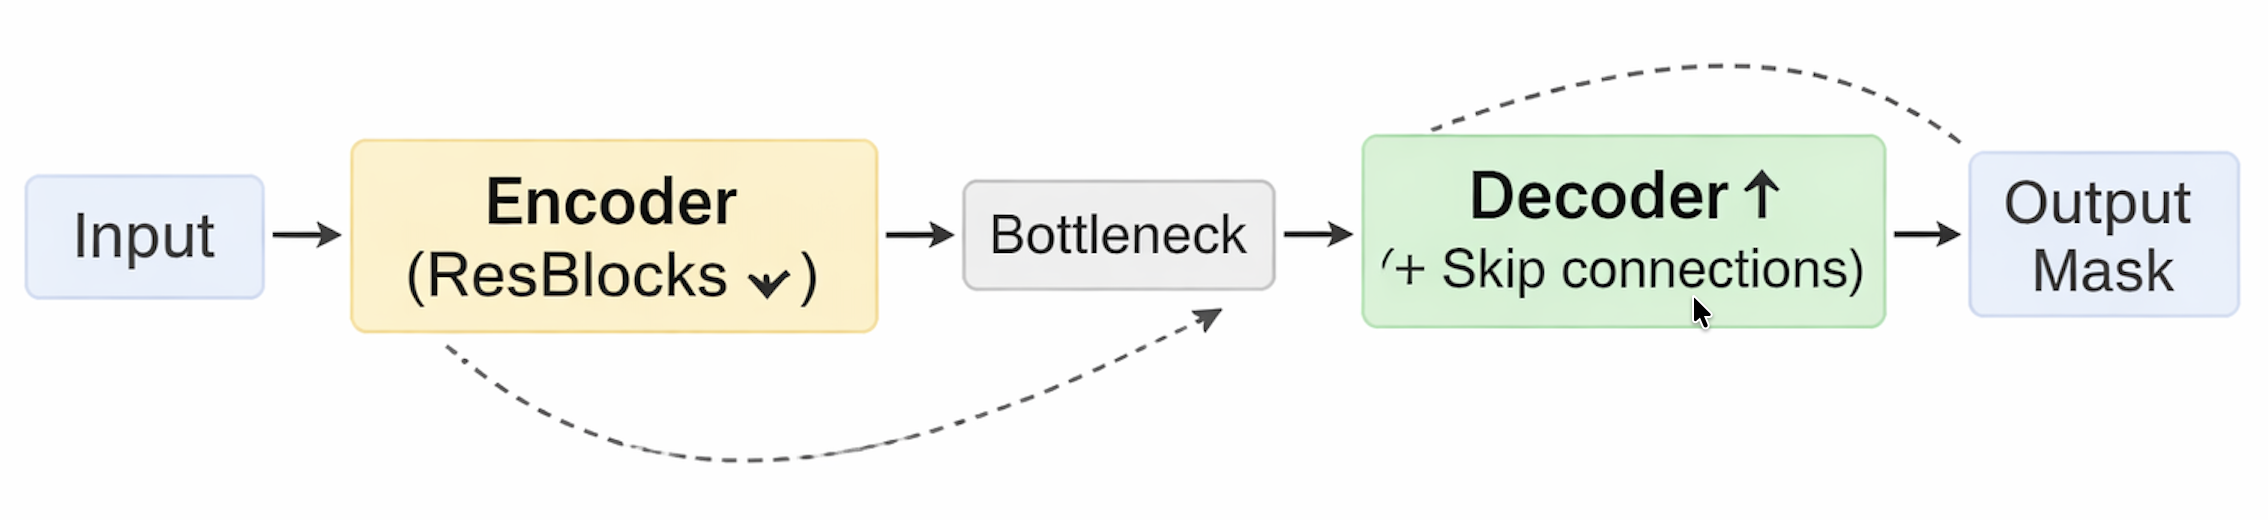

In [13]:
# Builing the network
class Cnn_network(nn.Module):
  def __init__(self, num_class):
    super(Cnn_network, self).__init__()

    # Encoder
    self.block1 = nn.Sequential(
        ResidualBlock(3, 32, stride=2),
        ResidualBlock(32, 32, stride=1)
    )

    self.block2 = nn.Sequential(
        ResidualBlock(32, 64, stride=2),
        ResidualBlock(64, 64, stride=1)
    )

    self.block3 = nn.Sequential(
        ResidualBlock(64, 128, stride=2),
        ResidualBlock(128, 128, stride=1)
    )

    self.block4 = nn.Sequential(
        ResidualBlock(128, 256, stride=2),
        ResidualBlock(256, 256, stride=1)
    )

    self.dropout = nn.Dropout2d(0.3)

    # Decoder
    self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
    self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
    self.up3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
    self.up4 = nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2)

    self.conv1 = ResidualBlock(256, 128, stride=1)
    self.conv2 = ResidualBlock(128, 64, stride=1)
    self.conv3 = ResidualBlock(64, 32, stride=1)
    self.conv4 = ResidualBlock(32, 32, stride=1)

    self.gap = nn.AdaptiveAvgPool2d((1, 1))

    self.final = nn.Linear(32, 16)
    self.box_head = nn.Linear(16, num_class)



  def forward(self, x):

    # Encoder
    x1 = self.block1(x)
    x2 = self.block2(x1)
    x3 = self.block3(x2)
    x4 = self.block4(x3) # <-- Bottleneck
    x4 = self.dropout(x4) # <-- reduce noise at bottleneck

    # Decoder
    x = self.up1(x4)
    x = nn.functional.interpolate(x, size=x3.shape[2:])
    x = torch.cat([x, x3], dim=1)
    x = self.conv1(x)

    x = self.up2(x)
    x = nn.functional.interpolate(x, size=x2.shape[2:])
    x = torch.cat([x, x2], dim=1)
    x = self.conv2(x)

    x = self.up3(x)
    x = nn.functional.interpolate(x, size=x1.shape[2:])
    x = torch.cat([x, x1], dim=1)
    x = self.conv3(x)

    x = self.up4(x)
    x = self.conv4(x)

    x = self.gap(x)
    x = torch.flatten(x, 1)
    x = self.final(x)
    x = torch.sigmoid(self.box_head(x))
    return x
net = Cnn_network(4).to(device)
net

Cnn_network(
  (block1): Sequential(
    (0): ResidualBlock(
      (conv): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (skip): Sequential(
        (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(2, 2))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): ResidualBlock(
      (conv): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     

In [42]:
# test the model
dumy_dataset = torch.randn(2, 3, 300, 300).to(device)
# test the model
pred = net(dumy_dataset)
pred

tensor([[0.5556, 0.4553, 0.5408, 0.5558],
        [0.5558, 0.4556, 0.5411, 0.5560]], device='cuda:0',
       grad_fn=<SigmoidBackward0>)

In [43]:
# define the compiler
optimizer = torch.optim.AdamW(params=net.parameters(), lr=0.0002, weight_decay=0.0001)
# ↑ (Adam with Weight Decay) decouples these, leading to better generalization more consistant decay

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, # Drops the learning rate when the validation loss stops improving
                                                       mode='min',
                                                       patience=2,
                                                       factor=0.5)
loss_fun = nn.SmoothL1Loss()

In [30]:
# training method
def train(data_loader, loss_fun, optimizer):
  # print(f'is training: {net.training}')
  size = len(data_loader.dataset)
  training_loss = 0
  number_of_batches = len(data_loader)

  net.train(mode=True) # set the model in the training mode
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)

    # y = y.unsqueeze(1).float()
    # reset all the gradient
    optimizer.zero_grad()

    output = net(X) # <-- directly calling the forward method
    loss = loss_fun(output, y) # calculate the error
    # print(f"loss: {loss} output: {output.shape}")
    loss.backward() # compute the gradient
    # at this point we computed the gradient

    optimizer.step() # update the weights
    training_loss += loss.item()
    if (batch+1 == number_of_batches):
      print(f'Batch {batch+1}/{number_of_batches} | Loss: {loss.item():.4f}')

  return training_loss/number_of_batches


In [31]:
# Validate the model
def val_model(data_loader, loss_fun):
  val_loss = 0
  net.eval()
  with torch.no_grad(): # disable the grade calculation
    for data in data_loader:
      X, y = data
      X, y = X.to(device), y.to(device)
      # y = y.unsqueeze(1).float()

      output = net(X)

      loss = loss_fun(output, y)
      val_loss += loss.item()
  return val_loss/len(data_loader)

In [46]:
img, label = ben_train_loader.dataset.__getitem__(0)
img.shape

torch.Size([3, 300, 300])

In [41]:
epoch = 12
history = {'tr_loss': [], 'val_loss': []}
best_val = float('inf')
patience = 3
counter = 0
best_epoch = 0
for i in range(epoch):
  print(f"Epoch {i}: ")
  tr_loss = train(ben_train_loader, loss_fun, optimizer)
  history['tr_loss'].append(tr_loss)
  avg_loss = val_model(ben_valid_loader, loss_fun)

  # update the learning rate
  scheduler.step(round(avg_loss, 4)) # <-- reduces noise sensitivity
  history['val_loss'].append(avg_loss)
  print(f"Validation loss: {avg_loss}")

  if avg_loss < best_val:
      best_val = avg_loss
      counter = 0
      best_epoch = i
      torch.save(net.state_dict(), "best_model.pth")
  else:
      counter += 1

  if counter >= patience:
      print("Early stopping!")
      break
print(f"Best model at epoch {best_epoch}")

<Axes: >

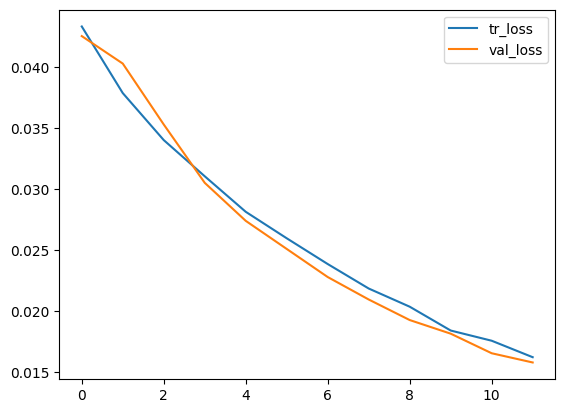

In [48]:
# Plot the loss curve
pd.DataFrame(history).plot()

In [28]:
model_path = '/content/drive/MyDrive/Healthcare/BUSI/Models/bbox_m1.pt'

In [51]:
# save the model
torch.save(net.state_dict(), model_path)

In [ ]:
# load the model
model = Cnn_network(num_class=4).to(device)

state_dict = torch.load(model_path, weights_only=True, map_location=torch.device('cpu'))
model.load_state_dict(state_dict)

model.eval()

In [30]:
# Get the test dataset
benign_test = Dataset(test_data, test_mask, 'benign', 'benign_mask', transform=validation_transform_pipeline, image_size=img_size)
ben_test_loader = torch.utils.data.DataLoader(benign_test, shuffle=False, batch_size=16, drop_last=False, num_workers=2 )

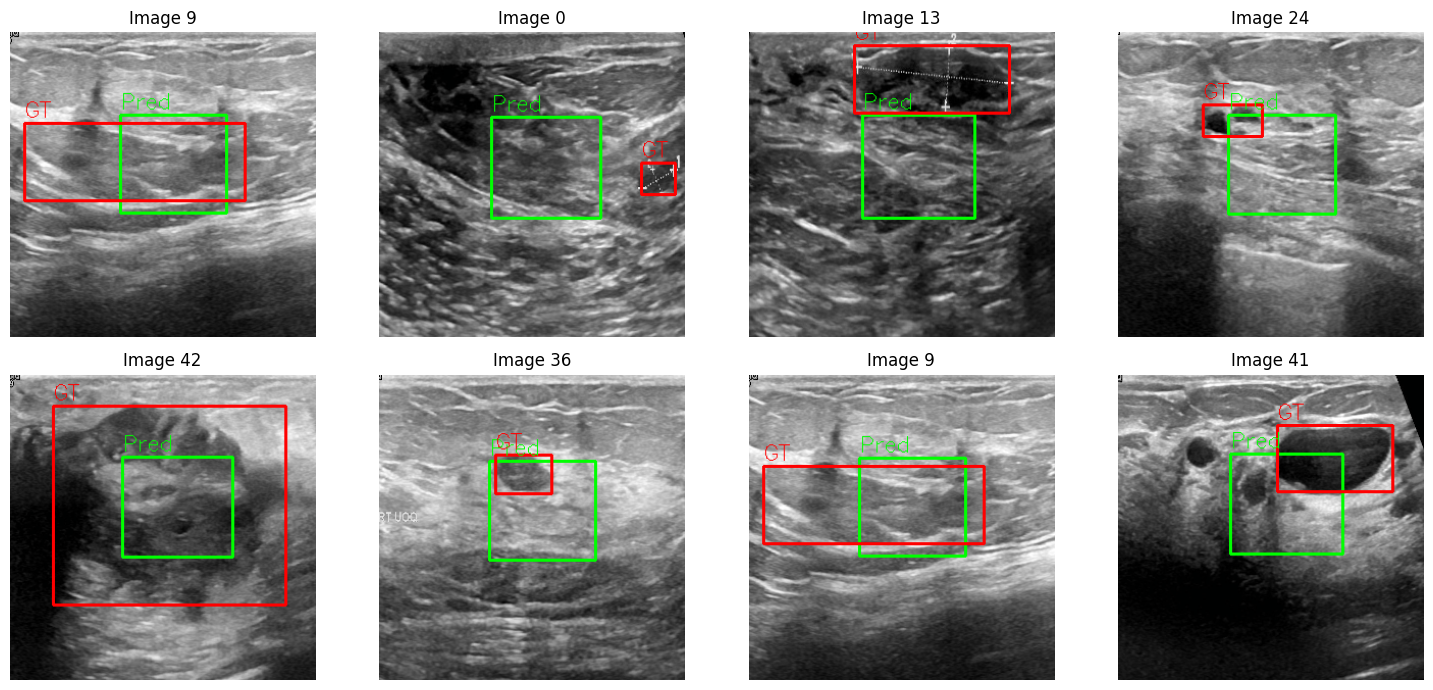

In [31]:

plt.figure(figsize=(15, 7))
for i in range(8):
  idx = np.random.randint(len(ben_test_loader.dataset))
  img, bbox = ben_test_loader.dataset[idx]
  pred_test = model(img.unsqueeze(0).to(device))

  img = img.permute(1,2,0).cpu().numpy()
  h_img, w_img, _ = img.shape

  x, y, w, h = pred_test[0].detach().cpu()

  # 1. convert to pixel space
  x = x.item() * w_img
  y = y.item() * h_img
  w = w.item() * w_img
  h = h.item() * h_img

  # 2. fix negatives
  x = max(0, int(x))
  y = max(0, int(y))
  w = max(1, int(w))
  h = max(1, int(h))

  # ground truth
  tx, ty, tw, th = bbox
  tx = tx.item()* w_img
  ty = ty.item()* h_img
  tw = tw.item()* w_img
  th = th.item()* h_img
  tx, ty, tw, th = map(int, [tx, ty, tw, th])

  img_copy = denormalize(img.copy())

  # draw predicted (green)
  cv2.rectangle(img_copy, (x, y), (x+w, y+h), (0, 255, 0), 2)

  # draw ground truth (red)
  cv2.rectangle(img_copy, (tx, ty), (tx+tw, ty+th), (255, 0, 0), 2)


  cv2.putText(img_copy, "Pred", (x, y-6),
              cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 1)

  cv2.putText(img_copy, "GT", (tx, ty-6),
              cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 1)
  plt.subplot(2, 4, i+1)
  plt.imshow(img_copy)
  plt.title(f'Image {idx}')
  plt.axis("off")
plt.tight_layout()

# Fine Tuning the pretrained model

In [14]:
# Create a Augmentation Pipeline
img_size = 300
train_transform_pipeline = A.Compose([
    A.Resize(img_size, img_size),

    # Geometric
    A.HorizontalFlip(p=0.3),

    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.05,
        rotate_limit=10,
        p=0.2
    ),

    # Light intensity changes
    A.RandomBrightnessContrast(p=0.2),
    A.GaussNoise(std_range=(0.05, 0.2), p=0.1),

    A.Normalize(mean=g_mean, std=g_std ),
    A.pytorch.ToTensorV2(),
],
bbox_params=A.BboxParams(format='coco', min_visibility=0.3, label_fields=[]))

validation_transform_pipeline = A.Compose([
    A.Resize(img_size, img_size),
    A.Normalize(mean=g_mean, std=g_std ),
    A.pytorch.ToTensorV2(),
],
bbox_params=A.BboxParams(format='coco', min_visibility=0.3, label_fields=[]))

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [15]:
# Get all the dataset
train_data, val_data, test_data = split_dataset(benign)
train_mask, val_mask, test_mask = split_dataset(benign_mask)
benign_train = Dataset(train_data, train_mask, 'benign', 'benign_mask', transform=train_transform_pipeline, image_size=img_size)
benign_val = Dataset(val_data, val_mask, 'benign', 'benign_mask', transform=validation_transform_pipeline, image_size=img_size)
benign_test = Dataset(test_data, test_mask, 'benign', 'benign_mask', transform=validation_transform_pipeline, image_size=img_size)

In [18]:
start_time = time()
train_dir = "benign_dataset_fin_tuning/train"
val_dir = "benign_dataset_fin_tuning/val"
# create directory if it doesn't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
for i in range(len(benign_train)):
    tr_image, tr_label = benign_train[i]   # <-- NOW data is loaded
    torch.save((tr_image, tr_label), f"{train_dir}/benign_{i}.pt")

for i in range(len(benign_val)):
    val_image, val_label = benign_val[i]
    torch.save((val_image, val_label), f"{val_dir}/benign_{i}.pt")
print(f'tokes {time()-start_time}s')

tokes 6.623573064804077s


In [19]:
train_dataset = CachedDataset(train_dir)
val_dataset = CachedDataset(val_dir)
len(train_dataset), len(val_dataset)

(305, 87)

In [20]:
# add data loader
ben_train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=32, num_workers=2, shuffle=True, drop_last=True)
ben_valid_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=32, num_workers=2, shuffle=True)

In [49]:
# define the compiler
optimizer = torch.optim.AdamW(params=net.parameters(), lr=0.00003, weight_decay=0.0001)
# ↑ (Adam with Weight Decay) decouples these, leading to better generalization more consistant decay

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, # Drops the learning rate when the validation loss stops improving
                                                       mode='min',
                                                       patience=3,
                                                       factor=0.5)

In [22]:
def bbox_iou(pred, target, eps=1e-6):
    # pred, target: (B, 4)

    x1 = torch.max(pred[:, 0], target[:, 0])
    y1 = torch.max(pred[:, 1], target[:, 1])
    x2 = torch.min(pred[:, 2], target[:, 2])
    y2 = torch.min(pred[:, 3], target[:, 3])

    # intersection
    inter_w = (x2 - x1).clamp(min=0)
    inter_h = (y2 - y1).clamp(min=0)
    intersection = inter_w * inter_h

    # areas
    area_pred = (pred[:, 2] - pred[:, 0]) * (pred[:, 3] - pred[:, 1])
    area_target = (target[:, 2] - target[:, 0]) * (target[:, 3] - target[:, 1])

    union = area_pred + area_target - intersection + eps

    iou = intersection / union
    return iou


In [23]:
def iou_loss(pred, target):
    iou = bbox_iou(pred, target)
    return 1 - iou.mean()

In [37]:
def combined_loss(pred, target):
    l1 = torch.nn.SmoothL1Loss()(pred, target)
    return l1
    # iou = iou_loss(pred, target)
    # return 0.7 * l1 + 0.3 * iou

In [32]:
# training method
def train(data_loader, loss_fun, optimizer, model):
  # print(f'is training: {net.training}')
  size = len(data_loader.dataset)
  training_loss = 0
  number_of_batches = len(data_loader)

  model.train(mode=True) # set the model in the training mode
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)

    # y = y.unsqueeze(1).float()
    # reset all the gradient
    optimizer.zero_grad()

    output = model(X) # <-- directly calling the forward method
    loss = loss_fun(output, y) # calculate the error
    # print(f"loss: {loss} output: {output.shape}")
    loss.backward() # compute the gradient
    # at this point we computed the gradient

    optimizer.step() # update the weights
    training_loss += loss.item()
    if (batch+1 == number_of_batches):
      print(f'Batch {batch+1}/{number_of_batches} | Loss: {loss.item():.4f}')

  return training_loss/number_of_batches


In [33]:
# Validate the model
def val_model(data_loader, loss_fun, model):
  val_loss = 0
  model.eval()
  with torch.no_grad(): # disable the grade calculation
    for data in data_loader:
      X, y = data
      X, y = X.to(device), y.to(device)
      # y = y.unsqueeze(1).float()

      output = model(X)

      loss = loss_fun(output, y)
      val_loss += loss.item()
  return val_loss/len(data_loader)

In [50]:
epoch = 25
history = {'tr_loss': [], 'val_loss': []}
best_val = float('inf')
patience = 10
counter = 0
best_epoch = 0
for i in range(epoch):
  print(f"Epoch {i}: ")
  tr_loss = train(ben_train_loader, combined_loss, optimizer, model)
  history['tr_loss'].append(tr_loss)
  avg_loss = val_model(ben_valid_loader, combined_loss, model)

  # update the learning rate
  scheduler.step(round(avg_loss, 4)) # <-- reduces noise sensitivity
  history['val_loss'].append(avg_loss)
  print(f"Validation loss: {avg_loss}")

  if avg_loss < best_val:
      best_val = avg_loss
      counter = 0
      best_epoch = i
      torch.save(net.state_dict(), "best_model.pth")
  else:
      counter += 1

  if counter >= patience:
      print("Early stopping!")
      break
print(f"Best model at epoch {best_epoch}")

Epoch 0: 
Batch 9/9 | Loss: 0.0123
Validation loss: 0.015385651029646397
Epoch 1: 
Batch 9/9 | Loss: 0.0135
Validation loss: 0.01510867973168691
Epoch 2: 
Batch 9/9 | Loss: 0.0141
Validation loss: 0.015466984671851
Epoch 3: 
Batch 9/9 | Loss: 0.0159
Validation loss: 0.015560273081064224
Epoch 4: 
Batch 9/9 | Loss: 0.0125
Validation loss: 0.015242828366657099
Epoch 5: 
Batch 9/9 | Loss: 0.0152
Validation loss: 0.015368441119790077
Epoch 6: 
Batch 9/9 | Loss: 0.0173
Validation loss: 0.015391994888583818
Epoch 7: 
Batch 9/9 | Loss: 0.0143
Validation loss: 0.015407448634505272
Epoch 8: 
Batch 9/9 | Loss: 0.0141
Validation loss: 0.015608510623375574
Epoch 9: 
Batch 9/9 | Loss: 0.0169
Validation loss: 0.015463723490635553
Epoch 10: 
Batch 9/9 | Loss: 0.0168
Validation loss: 0.015367040721078714
Epoch 11: 
Batch 9/9 | Loss: 0.0173
Validation loss: 0.015481923396388689
Early stopping!
Best model at epoch 1


<Axes: >

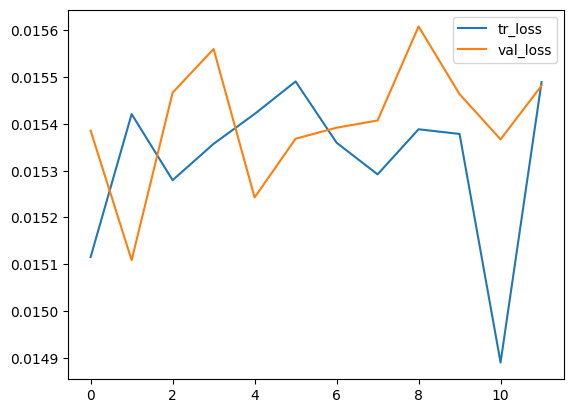

In [51]:
pd.DataFrame(history).plot()

In [43]:
# Get the test dataset
benign_test = Dataset(test_data, test_mask, 'benign', 'benign_mask', transform=validation_transform_pipeline, image_size=img_size)
ben_test_loader = torch.utils.data.DataLoader(benign_test, shuffle=False, batch_size=16, drop_last=False, num_workers=2 )

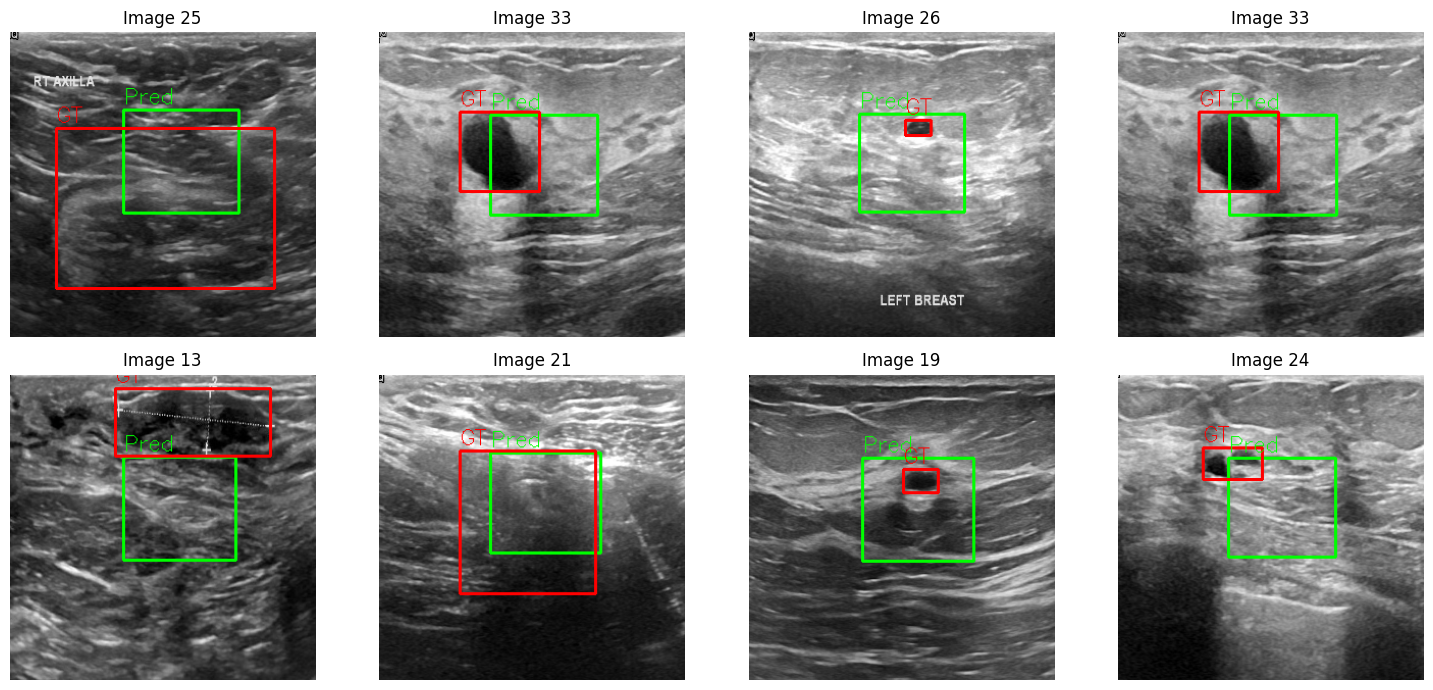

In [54]:

plt.figure(figsize=(15, 7))
for i in range(8):
  idx = np.random.randint(len(ben_test_loader.dataset))
  img, bbox = ben_test_loader.dataset[idx]
  pred_test = model(img.unsqueeze(0).to(device))

  img = img.permute(1,2,0).cpu().numpy()
  h_img, w_img, _ = img.shape

  x, y, w, h = pred_test[0].detach().cpu()

  # 1. convert to pixel space
  x = x.item() * w_img
  y = y.item() * h_img
  w = w.item() * w_img
  h = h.item() * h_img

  # 2. fix negatives
  x = max(0, int(x))
  y = max(0, int(y))
  w = max(1, int(w))
  h = max(1, int(h))

  # ground truth
  tx, ty, tw, th = bbox
  tx = tx.item()* w_img
  ty = ty.item()* h_img
  tw = tw.item()* w_img
  th = th.item()* h_img
  tx, ty, tw, th = map(int, [tx, ty, tw, th])

  img_copy = denormalize(img.copy())

  # draw predicted (green)
  cv2.rectangle(img_copy, (x, y), (x+w, y+h), (0, 255, 0), 2)

  # draw ground truth (red)
  cv2.rectangle(img_copy, (tx, ty), (tx+tw, ty+th), (255, 0, 0), 2)


  cv2.putText(img_copy, "Pred", (x, y-6),
              cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 1)

  cv2.putText(img_copy, "GT", (tx, ty-6),
              cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 1)
  plt.subplot(2, 4, i+1)
  plt.imshow(img_copy)
  plt.title(f'Image {idx}')
  plt.axis("off")
plt.tight_layout()